In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850


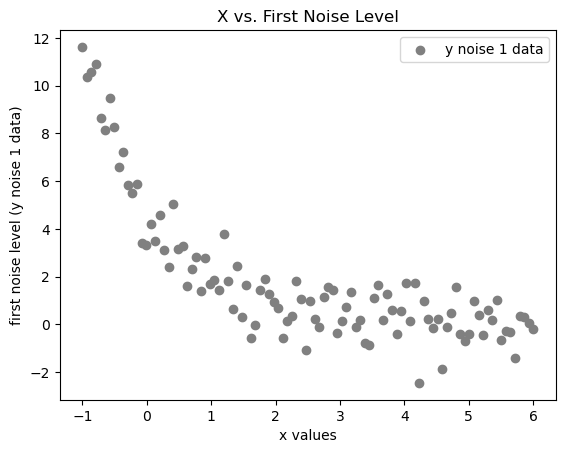

In [6]:
# -- 2.1 Collect the Data --
df = pd.read_csv("../../course_assignments/homework9/noisy_curvefit_data.csv")

# 4)
# The shape is (100, 6)
# There are 100 rows and 6 columns
print(df.head(5))
print(df.tail(5))
# The column names are x, y_noise_1, y_noise_2, y_noise_3, y_noise_4, y_noise_5

# 5)
x = df['x']
y_noise_1 = df['y_noise_1']
plt.scatter(df['x'], df['y_noise_1'], color = 'gray', label = 'y noise 1 data')
plt.xlabel('x values')
plt.ylabel('first noise level (y noise 1 data)')
plt.title('X vs. First Noise Level')
plt.legend()
plt.show()

Fit: y = 4.71 * e^(-0.92 * x)


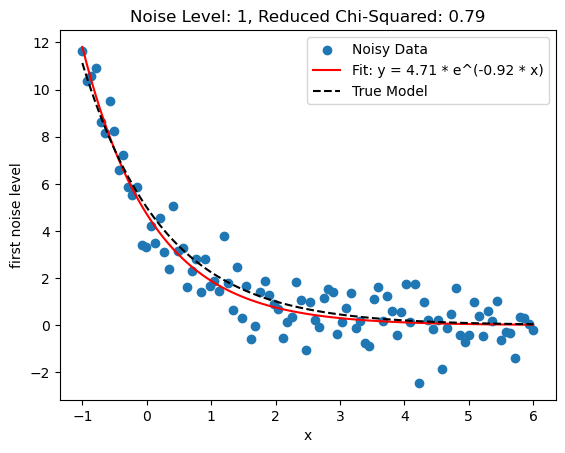

In [8]:
# -- 2.2 Fit the Data --
def model(x, A, k):
    return A * np.exp(-k * x)

p0 = [1, 1]

popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)
A_fit, k_fit = popt
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")
residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof
plt.scatter(x, y_noise_1, label = 'Noisy Data')
plt.plot(x, model(x, A_fit, k_fit), 'r-', label = f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")
plt.plot(x, model(x, 5, 0.8), 'k--', label = 'True Model')
noise_level = 1
title_text = f"Noise Level: {noise_level}, Reduced Chi-Squared: {chi2_reduced:.2f}"
plt.title(title_text)
plt.xlabel('x')
plt.ylabel('first noise level')
plt.legend()
plt.show()


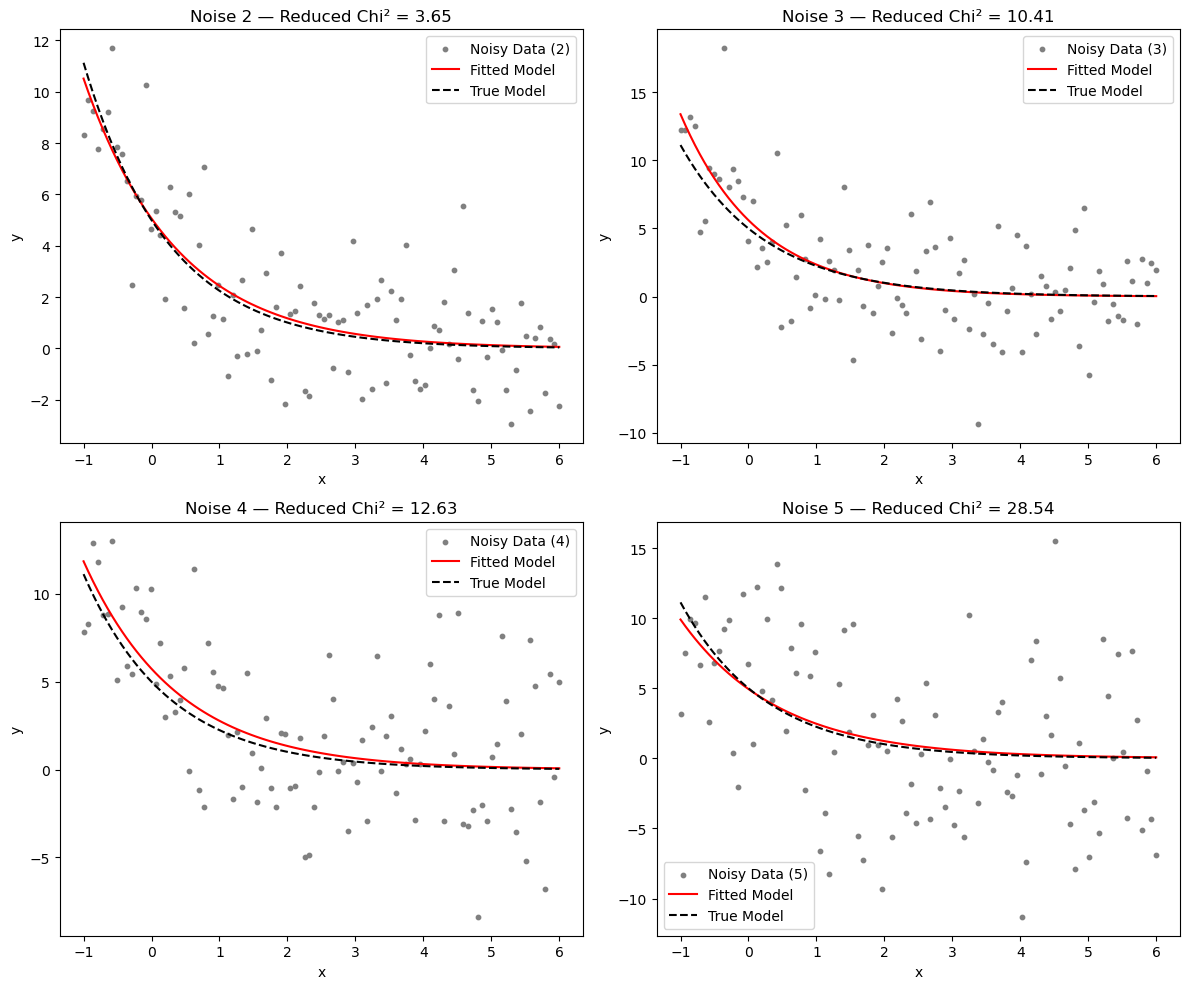

Saved noisy_parameters.csv


In [11]:
# -- 2.3 Compare Different Noise Levels --
def fit_model(x, y):
    popt, pcov = curve_fit(model, x, y, p0=[1, 1])
    A_fit, k_fit = popt

    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof

    return A_fit, k_fit, chi2_reduced
noise_cols = ["y_noise_2", "y_noise_3", "y_noise_4", "y_noise_5"]
fig, axs = plt.subplots(2, 2, figsize=(12,10))
axs = axs.flatten()
results = []

for i, col in enumerate(noise_cols):
    y = df[col].values
    A_fit, k_fit, chi2_r = fit_model(x, y)
    results.append([i+2, A_fit, k_fit, chi2_r])
    ax = axs[i]
    ax.scatter(x, y, color="gray", s=10, label=f"Noisy Data ({i+2})")
    ax.plot(x, model(x, A_fit, k_fit), "r", label="Fitted Model")
    ax.plot(x, model(x, 5, 0.8), "k--", label="True Model")
    ax.set_title(f"Noise {i+2} — Reduced Chi² = {chi2_r:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

plt.tight_layout()
plt.show()

# -- 2.4 Save Your Results --
summary_df = pd.DataFrame(
    results,
    columns=["Noise Level", "A_fit", "k_fit", "chi2_reduced"]
)
summary_df
summary_df.to_csv("noisy_parameters.csv", index=False)
print("Saved noisy_parameters.csv")